## Análisis Multivariable de los datos

### By: Maricel Martinez

### Date: 2026-08-27

### Description:

Análisis exploratorio multivariable (EDA) para estudiar cómo interactúan conjuntamente varias variables con la variable objetivo `medv`, y para construir un modelo heurístico simple como línea base.

### Alcance

Este notebook continúa el análisis exploratorio del proyecto `Precios-casas-Boston`, a partir de los análisis univariable (`03_EDA_univariable`) y bivariable (`04_EDA_bivariable`) ya realizados. Se retoman los principales hallazgos de esas etapas:

- `rm` y `lstat` son las variables individualmente más asociadas con `medv` (0.69 y -0.74).
- `chas` tiene asociación débil (0.19) pero un boxplot con diferencia visible entre grupos.
- `rad` tiene asociación moderada (-0.35), impulsada principalmente por el grupo `rad = 24`.
- `tax` y `rad` están fuertemente correlacionadas entre sí (0.91), dominadas por ese mismo grupo `rad = 24` (impuesto casi constante en 666).
- `medv` muestra un patrón visible de censura/truncamiento en su valor máximo (50).

En este notebook se combinan tres o más variables a la vez para revisar si estos patrones se mantienen, se refuerzan o cambian al considerarlos en conjunto. No se entrena un modelo de Machine Learning definitivo; solo se construye un modelo heurístico simple como línea base.

## 📚 Import libraries

In [18]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración

In [19]:
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")

# Versiones

In [20]:
print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("Seaborn version:", sns.__version__)

Python version: 3.12.13 (main, Aug  5 2026, 15:44:22) [Clang 22.1.3 ]
Pandas version: 3.0.5
Seaborn version: 0.13.2


## 💾 Load data

In [21]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

boston_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/boston_type_fixed.parquet",
    engine="pyarrow",
)

# Comprensión general de los datos (recordatorio)

In [22]:
boston_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     339 non-null    float64
 1   zn       343 non-null    float64
 2   indus    339 non-null    float64
 3   chas     343 non-null    float64
 4   nox      341 non-null    float64
 5   rm       340 non-null    float64
 6   age      342 non-null    float64
 7   dis      340 non-null    float64
 8   rad      342 non-null    float64
 9   tax      340 non-null    float64
 10  ptratio  342 non-null    float64
 11  black    341 non-null    float64
 12  lstat    343 non-null    float64
 13  medv     331 non-null    float64
dtypes: float64(14)
memory usage: 37.6 KB


In [23]:
print("Número de filas:", boston_df.shape[0])
print("Número de columnas:", boston_df.shape[1])

Número de filas: 343
Número de columnas: 14


# Definición de variables para el análisis multivariable

In [24]:
TARGET = "medv"

# variables con mayor asociación individual con medv (según el análisis bivariable)
top_vars = ["rm", "lstat", "ptratio", "indus", "tax"]

# variable auxiliar: separa el grupo rad = 24 (dominante y con precios bajos)
# del resto de valores de rad, según lo encontrado en el análisis bivariable
RAD_HIGH = 24

boston_df["rad_group"] = np.where(
    boston_df["rad"] == RAD_HIGH,
    "rad=24 (alto)",
    "rad<24",
)

print("Variable objetivo:", TARGET)
print("Variables de mayor asociación con medv:", top_vars)
print("Grupos de rad:", boston_df["rad_group"].unique().tolist())

Variable objetivo: medv
Variables de mayor asociación con medv: ['rm', 'lstat', 'ptratio', 'indus', 'tax']
Grupos de rad: ['rad<24', 'rad=24 (alto)']


### Interpretación de la definición de variables

Se construye `rad_group` como variable auxiliar categórica de dos niveles, a partir del hallazgo del análisis bivariable de que el grupo `rad = 24` se comporta de forma muy distinta al resto (precios más bajos, impuesto `tax` casi constante en 666). Esta variable facilita los cruces multivariables sin diluir el análisis en las nueve categorías originales de `rad`, la mayoría con pocas observaciones.

# medv vs rm vs chas

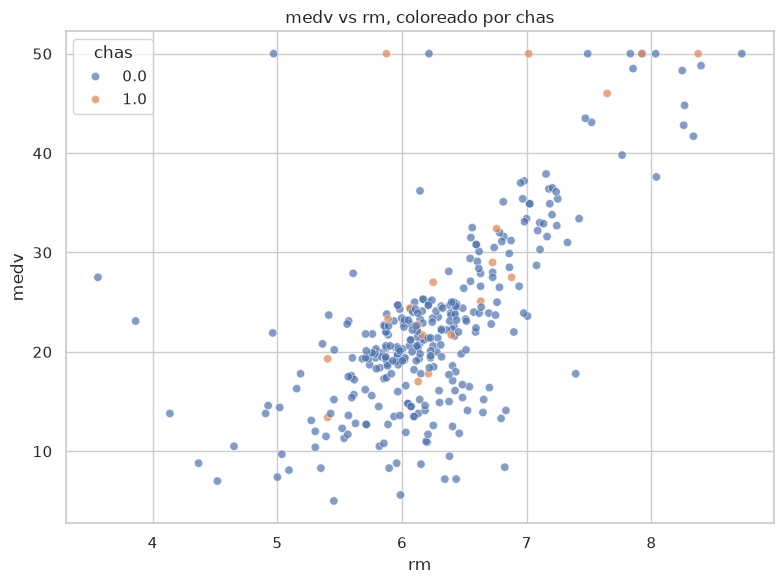

In [25]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=boston_df, x="rm", y=TARGET, hue="chas", alpha=0.7)
plt.title("medv vs rm, coloreado por chas")
plt.tight_layout()
plt.show()

### Interpretación de medv vs rm vs chas

Los puntos de `chas = 1` (naranja) se distribuyen mezclados con los de `chas = 0` a lo largo de toda la relación creciente entre `rm` y `medv`, sin ubicarse sistemáticamente por encima de la tendencia general. Esto sugiere que el efecto positivo de `chas` sobre `medv` visto en el bivariable no se manifiesta como un desplazamiento uniforme de toda la nube de puntos, sino que podría concentrarse en subgrupos específicos (se revisa en la tabla de medias por `chas` y `rad_group` más abajo).

# medv vs lstat vs chas

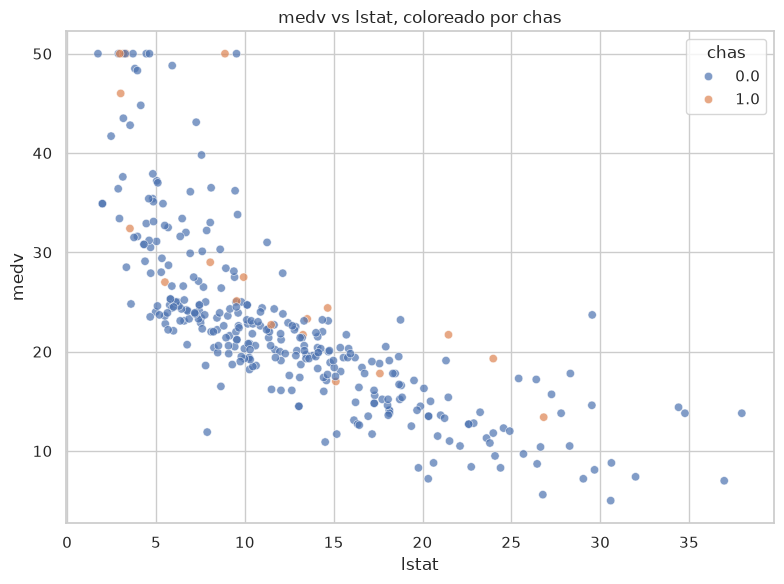

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=boston_df, x="lstat", y=TARGET, hue="chas", alpha=0.7)
plt.title("medv vs lstat, coloreado por chas")
plt.tight_layout()
plt.show()

### Interpretación de medv vs lstat vs chas

Los puntos de `chas = 1` siguen de cerca la misma curva descendente que los de `chas = 0`, sin concentrarse particularmente en valores bajos de `lstat` ni ubicarse por encima de la tendencia general. Esto indica que el efecto de `chas` no se explica simplemente porque esas viviendas tengan menor `lstat`; ambas variables parecen aportar información distinta sobre `medv`.

# medv vs rm vs grupo de rad

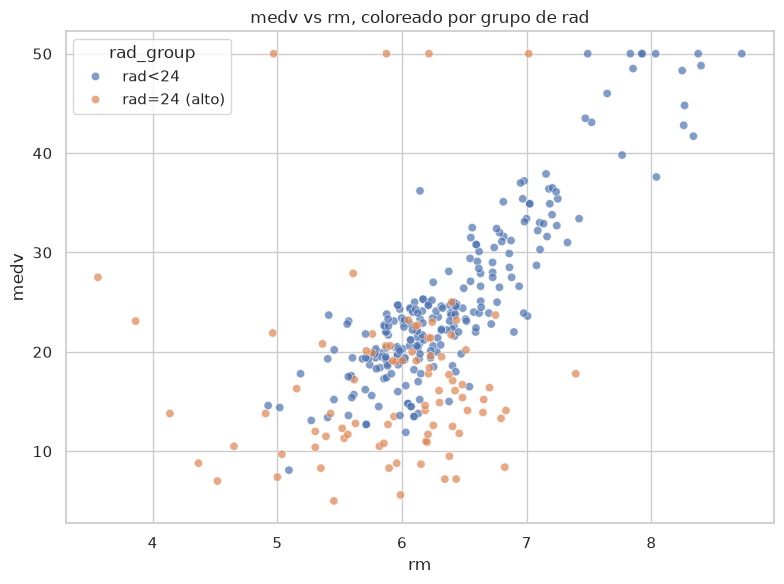

In [27]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=boston_df, x="rm", y=TARGET, hue="rad_group", alpha=0.7)
plt.title("medv vs rm, coloreado por grupo de rad")
plt.tight_layout()
plt.show()

### Interpretación de medv vs rm vs grupo de rad

Los puntos del grupo `rad = 24` (naranja) se ubican de forma visible por debajo de la tendencia general en el rango medio de `rm` (aproximadamente 5.5–7), con precios notablemente más bajos que los del grupo `rad < 24` para valores similares de `rm`. Esto confirma que el patrón visto en el bivariable no se explica por `rm`: dentro de este grupo, un número similar de habitaciones se traduce en un precio menor que en el resto del dataset, lo que apunta a otros factores asociados a `rad = 24` (como el `tax` casi constante en 666, ya detectado en el bivariable).

# medv agrupado por chas y grupo de rad

In [28]:
(
    boston_df.groupby(["chas", "rad_group"], observed=True)[TARGET].agg(
        ["mean", "median", "std", "count"]
    )
)

mean  median   std  count
chas rad_group                               
0.00 rad<24        24.48   22.80  8.11    230
     rad=24 (alto) 16.15   14.75  7.58     82
1.00 rad<24        29.01   26.05 11.74     14
     rad=24 (alto) 32.44   22.70 16.13      5

### Interpretación de medv por chas y grupo de rad

Dentro del grupo `rad < 24`, el efecto positivo de `chas` se mantiene: la media pasa de 24.48 (`chas = 0`) a 29.01 (`chas = 1`). Dentro del grupo `rad = 24`, el salto es aún mayor en apariencia (16.15 a 32.44), pero este subgrupo tiene solo 5 observaciones con una desviación estándar muy alta (16.13), y su mediana (22.70) es bastante menor que su media, lo que indica que uno o dos valores altos están inflando el promedio. Dado el tamaño tan reducido de este subgrupo, esta diferencia no debe interpretarse como un efecto confiable de `chas` dentro de `rad = 24`; más adelante se confirma que probablemente está relacionada con valores censurados de `medv`.

# Relación conjunta entre las variables más asociadas a medv

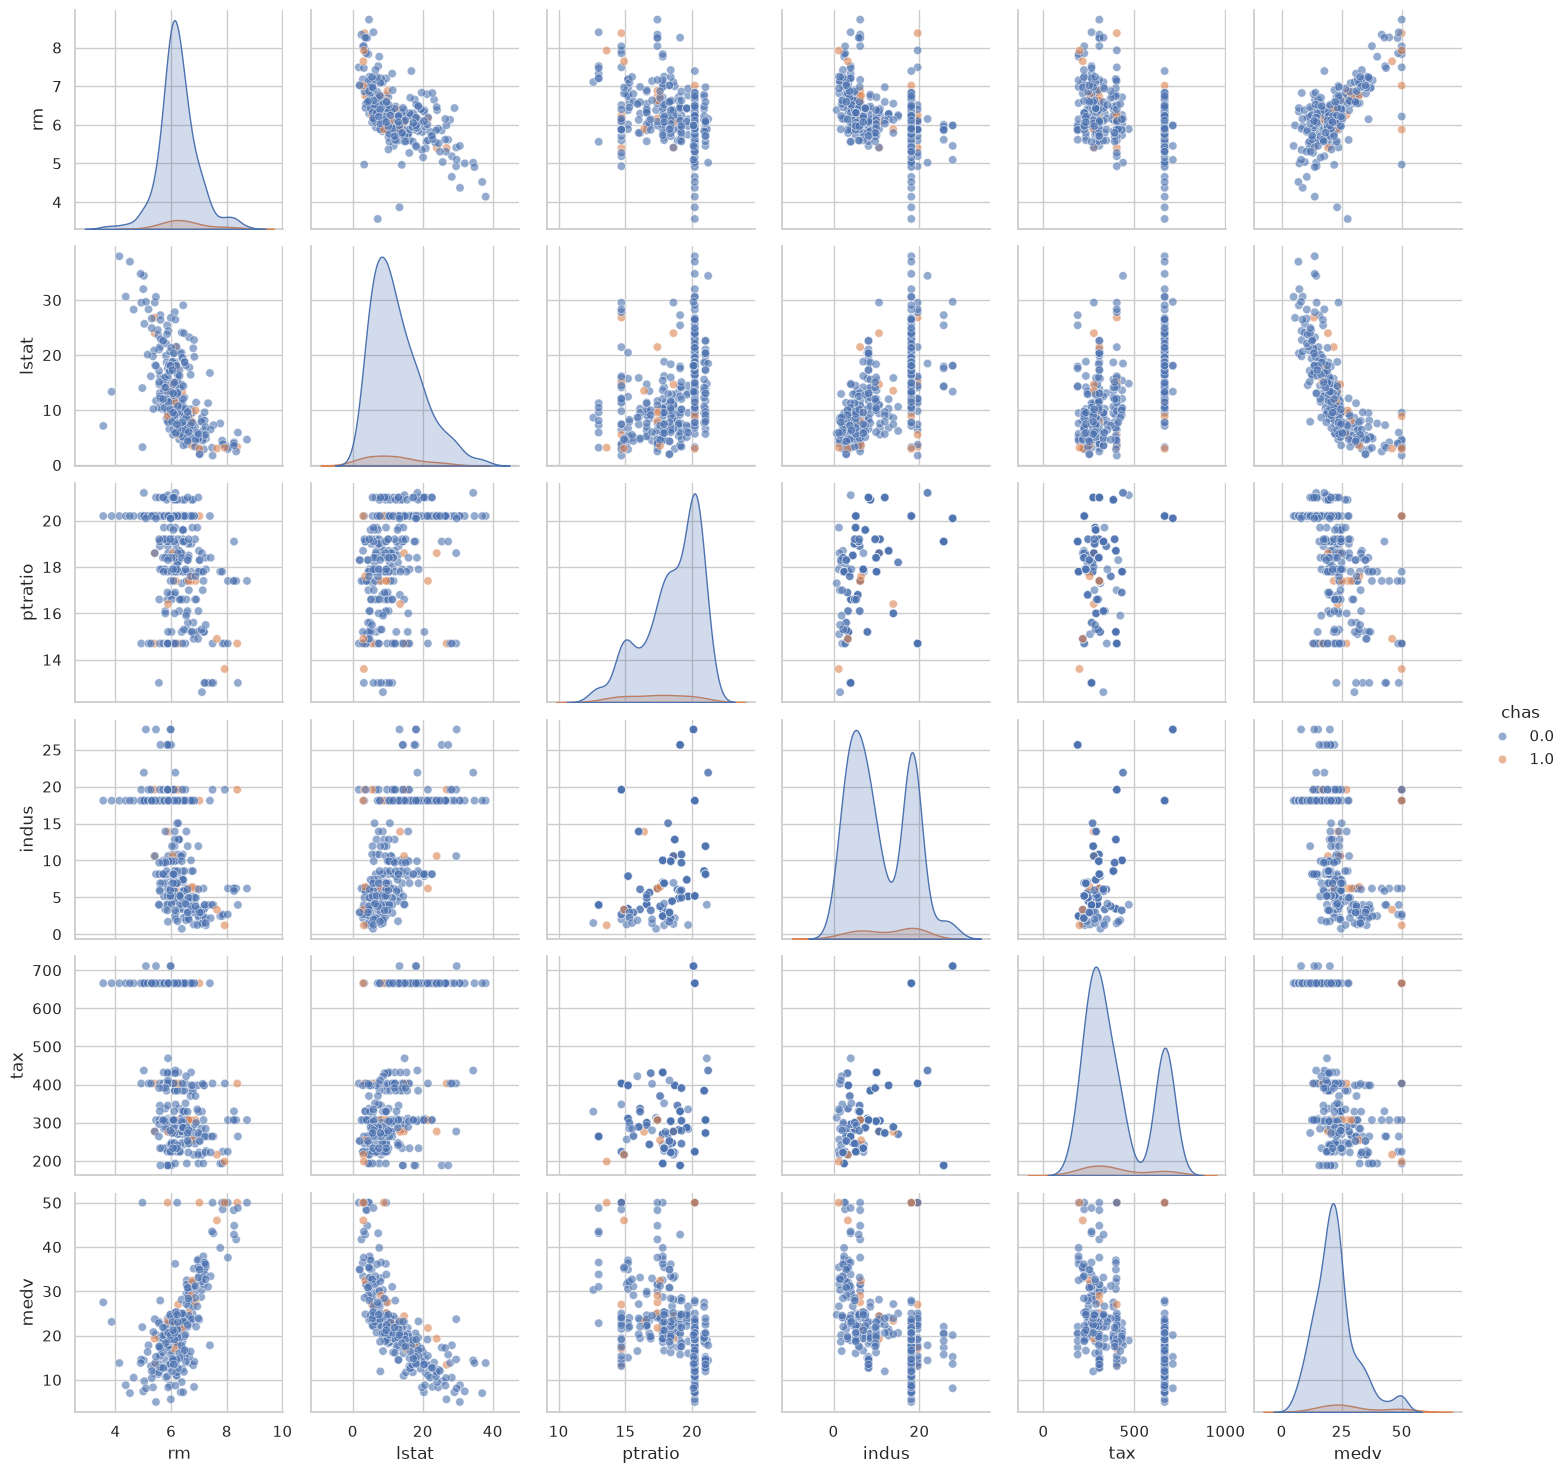

In [29]:
pairplot_vars = [*top_vars, TARGET]

sns.pairplot(
    boston_df[[*pairplot_vars, "chas"]].dropna(),
    hue="chas",
    diag_kind="kde",
    plot_kws={"alpha": 0.6},
)
plt.show()

### Interpretación del pairplot

La relación `rm`–`lstat` muestra con claridad la asociación negativa fuerte ya conocida (-0.62). `ptratio`, `indus` y `tax` muestran una distribución claramente bimodal, con concentraciones marcadas de puntos en dos bandas separadas (por ejemplo, `tax` alrededor de 660–700 frente a 200–400), consistente con el grupo `rad = 24` identificado antes. Los puntos de `chas = 1` (naranja) no forman un agrupamiento visualmente distinto dentro de este espacio de variables: aparecen dispersos entre los de `chas = 0` en casi todos los paneles, lo que refuerza que su efecto sobre `medv` es sutil y no está mediado obviamente por estas cinco variables.

# rm vs lstat, coloreado por medv

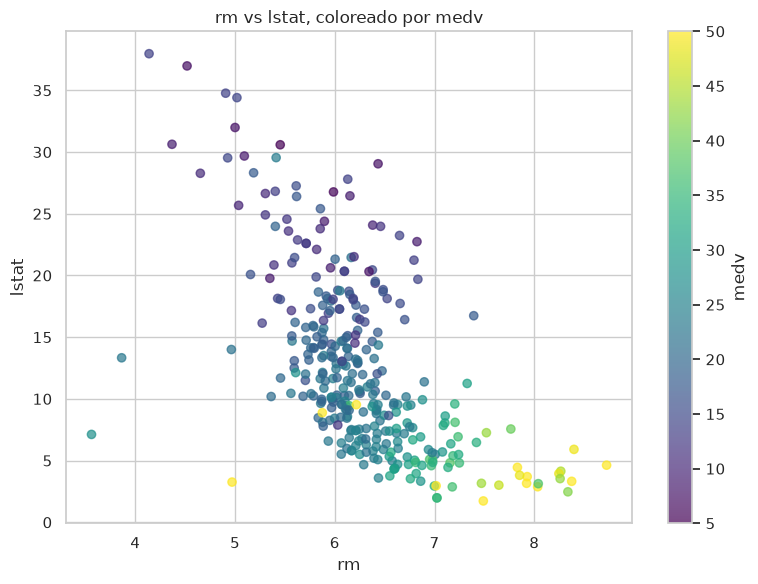

In [30]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    boston_df["rm"], boston_df["lstat"], c=boston_df[TARGET], cmap="viridis", alpha=0.7
)
plt.colorbar(scatter, label="medv")
plt.xlabel("rm")
plt.ylabel("lstat")
plt.title("rm vs lstat, coloreado por medv")
plt.tight_layout()
plt.show()

### Interpretación de rm vs lstat coloreado por medv

Se confirma el patrón esperado: los precios más altos (colores claros, amarillo/verde) se concentran en la región de `rm` alto y `lstat` bajo, mientras que los más bajos (colores oscuros) se concentran en `rm` bajo y `lstat` alto. Sin embargo, hay una excepción notable: un punto con `rm` bajo (~5) y `lstat` bajo (~3) aparece coloreado en amarillo (`medv = 50`), completamente fuera del patrón de sus vecinos, que tienen tonos verde/azul (`medv` entre 25 y 30) con valores similares de `rm` y `lstat`. Esta observación es un candidato claro a valor censurado: su precio no es consistente con el patrón general definido por `rm` y `lstat`, lo que refuerza la hipótesis de censura en `medv = 50`.

# Revisión de la posible censura de medv por grupo

In [31]:
MEDV_MAX = 50.0

censored = boston_df[boston_df[TARGET] == MEDV_MAX]

print("Observaciones con medv = 50.00:", len(censored))

censored.groupby(["chas", "rad_group"], observed=True).size()

Observaciones con medv = 50.00: 11


chas  rad_group    
0.00  rad<24           5
      rad=24 (alto)    2
1.00  rad<24           2
      rad=24 (alto)    2
dtype: int64

### Interpretación de la censura de medv por grupo

Se confirman 11 observaciones con `medv = 50.00`. Al revisar su proporción dentro de cada grupo, aparece un patrón claro: en `chas = 0` combinado con cualquier `rad_group`, la censura afecta solo entre el 2.2 % y el 2.4 % de las observaciones (5 de 230 y 2 de 82, respectivamente). En cambio, en `chas = 1` la proporción es mucho mayor: 14.3 % en `rad < 24` (2 de 14) y **40 %** en `rad = 24` (2 de 5). Esto explica directamente el salto inusual visto en la tabla de medias de la sección anterior: la media inflada de `medv` en el subgrupo `chas = 1` y `rad = 24` está determinada en gran parte por valores censurados, no por un efecto genuino y sostenido de `chas` dentro de ese segmento. Cualquier análisis o modelo que use ese subgrupo debe tener en cuenta este sesgo.

# 📏 Modelo heurístico de línea base

Se construye un modelo heurístico simple, basado en rangos de las dos variables con mayor asociación individual con `medv`: `rm` y `lstat`. El modelo estima el precio como la mediana de `medv` dentro de cada combinación de rangos, sin ajustar ningún parámetro ni usar librerías de Machine Learning.

In [32]:
def calculate_median_price(df, rm_min, rm_max, lstat_min, lstat_max):
    """Calcula la mediana de medv dentro de un rango de rm y lstat.

    Args:
        df: DataFrame con los datos de Boston
        rm_min: valor mínimo de rm (inclusive)
        rm_max: valor máximo de rm (exclusive)
        lstat_min: valor mínimo de lstat (inclusive)
        lstat_max: valor máximo de lstat (exclusive)

    Returns:
        tuple con la mediana de medv y el número de observaciones en el rango

    """
    subset = df[
        (df["rm"] >= rm_min)
        & (df["rm"] < rm_max)
        & (df["lstat"] >= lstat_min)
        & (df["lstat"] < lstat_max)
    ]
    return round(subset[TARGET].median(), 2), len(subset)


rm_ranges = [(3, 6), (6, 9)]
lstat_ranges = [(0, 10), (10, 40)]

for rm_range in rm_ranges:
    for lstat_range in lstat_ranges:
        median_price, n = calculate_median_price(boston_df, *rm_range, *lstat_range)
        print(
            f"rm en {rm_range}, lstat en {lstat_range}: mediana estimada = {median_price} (n={n})"
        )

rm en (3, 6), lstat en (0, 10): mediana estimada = 20.4 (n=15)
rm en (3, 6), lstat en (10, 40): mediana estimada = 17.8 (n=98)
rm en (6, 9), lstat en (0, 10): mediana estimada = 27.3 (n=136)
rm en (6, 9), lstat en (10, 40): mediana estimada = 18.5 (n=91)


### Interpretación del modelo heurístico

Los resultados confirman en general lo esperado: la combinación `rm` alto (6–9) y `lstat` bajo (0–10) produce la mediana más alta (27.3, n=136), y `rm` bajo (3–6) con `lstat` alto (10–40) produce una de las más bajas (17.8, n=98). Sin embargo, aparece un hallazgo interesante: cuando `lstat` es alto, el valor de `rm` deja de marcar una diferencia relevante — la mediana con `rm` alto y `lstat` alto (18.5, n=91) es prácticamente igual a la de `rm` bajo y `lstat` alto (17.8, n=98). Esto sugiere una posible interacción entre ambas variables: el beneficio de tener más habitaciones (`rm`) parece diluirse en zonas con `lstat` alto. El grupo `rm` bajo y `lstat` bajo (20.4) tiene solo 15 observaciones, por lo que su estimación es menos confiable que las demás.

## 📊 Análisis de resultados

`rm` y `lstat` se confirman como las variables de referencia para explicar `medv`: su combinación en el modelo heurístico y en el gráfico coloreado muestra el patrón esperado (precio alto con `rm` alto y `lstat` bajo, precio bajo en el extremo opuesto). Además, se identificó un posible efecto de interacción: el beneficio de un `rm` alto sobre el precio se reduce considerablemente en zonas con `lstat` alto.

El grupo `rad = 24`, ya señalado en el bivariable, mantiene precios sistemáticamente más bajos que el resto incluso controlando por `rm`, lo que confirma que su efecto sobre `medv` no se explica por el número de habitaciones.

El efecto de `chas` sobre `medv` se mantiene positivo dentro del grupo `rad < 24` (24.48 → 29.01), pero el salto observado dentro de `rad = 24` (16.15 → 32.44) resultó ser un artefacto: el 40 % de las observaciones de ese subgrupo (`chas = 1`, `rad = 24`) tienen `medv = 50`, frente a apenas 2–3 % en el resto de combinaciones. Esto confirma que la variable objetivo `medv` presenta censura en su valor máximo, y que esa censura no está distribuida uniformemente: afecta de forma desproporcionada a las viviendas junto al río (`chas = 1`), y de forma extrema al pequeño subgrupo que además tiene `rad = 24`.

El diagrama `rm` vs `lstat` coloreado por `medv` mostró un ejemplo concreto de este problema: una observación con `rm` y `lstat` bajos, que según el patrón general debería tener un precio moderado (~25-30), aparece registrada exactamente en 50, reforzando que ese valor no siempre refleja el comportamiento real de las variables predictoras.

## 💡 Propuestas e ideas

Como modelo heurístico de referencia, la combinación de `rm` y `lstat` (con las medianas ya calculadas por rango) ofrece una estimación razonable de `medv`, aunque debe usarse con cautela cuando `lstat` es alto, ya que en ese caso `rm` pierde poder explicativo.

Para las siguientes etapas se recomienda:

- Tratar de forma explícita las 11 observaciones con `medv = 50` antes de entrenar cualquier modelo de regresión (por ejemplo, excluirlas o marcarlas como censuradas), dado que no están distribuidas de forma uniforme y pueden sesgar los coeficientes, especialmente en los subgrupos con `chas = 1`.
- Evaluar el efecto de `chas` sobre `medv` únicamente dentro de `rad < 24`, donde hay suficientes observaciones (14 para `chas = 1`) para que la estimación sea algo más confiable; el subgrupo `chas = 1` y `rad = 24` (n=5) no es suficiente para sacar conclusiones sobre `chas` por sí solo.
- Considerar una variable de interacción entre `rm` y `lstat` en un futuro modelo, dado que su efecto conjunto no parece ser simplemente aditivo.
- Mantener la recomendación ya hecha en el bivariable de evitar incluir `tax` y `rad` simultáneamente sin tratamiento, por su alta colinealidad.

## 📖 References

- Ejemplo de análisis multivariable (dataset Titanic) — Jose R. Zapata, profesor del curso.
- https://joserzapata.github.io/courses/python-ciencia-datos/visualizacion/seaborn/
- https://www.kaggle.com/code/imkushwaha/bivariate-multivariate-analysis